In [36]:
import pandas as pd 
import json 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [37]:
baseline = pd.read_json('../localgpt/loss_tracker/baseline.json')
glu = pd.read_json('../localgpt/loss_tracker/glu.json')
rmsnorm = pd.read_json('../localgpt/loss_tracker/rmsnorm.json')
rope = pd.read_json('../localgpt/loss_tracker/rope.json')

In [38]:
rope.head(5)

,step,train,test
0,0,11.021471,11.022122
1,100,3.947241,3.939496
2,200,3.467940,3.468258
3,300,3.234106,3.236456
4,400,3.080016,3.077531


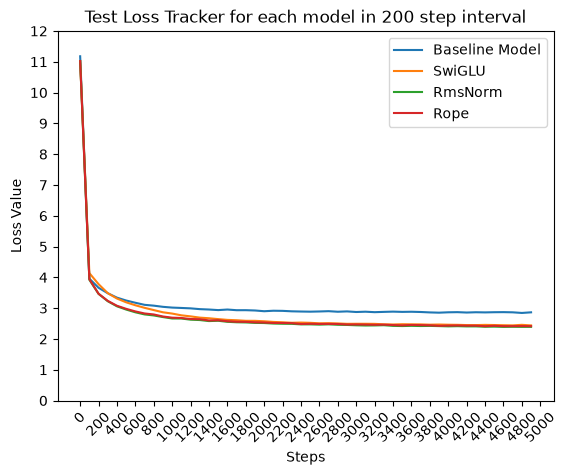

In [39]:
sns.lineplot(x = 'step', y = 'test', data = baseline, label = 'Baseline Model')
sns.lineplot(x = 'step', y = 'test', data = glu, label = 'SwiGLU')
sns.lineplot(x = 'step', y = 'test', data = rmsnorm, label = 'RmsNorm')
sns.lineplot(x = 'step', y = 'test', data = rope, label = 'Rope')
plt.xticks(np.arange(0,5001, 200), rotation = 45)
plt.yticks(np.arange(0,13,1))
plt.ylabel('Loss Value')
plt.xlabel('Steps')
plt.title('Test Loss Tracker for each model in 200 step interval')
plt.legend()
plt.show()

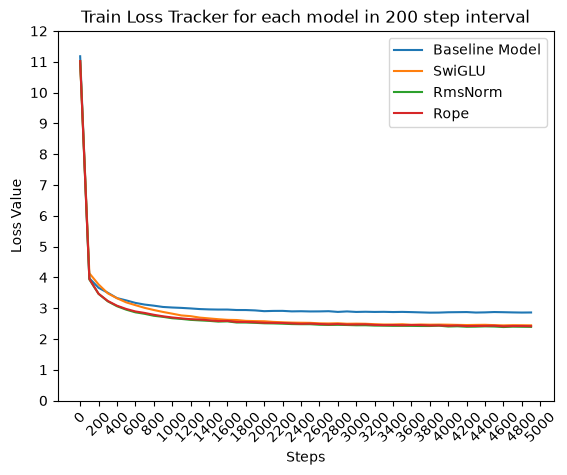

In [44]:
sns.lineplot(x = 'step', y = 'train', data = baseline, label = 'Baseline Model')
sns.lineplot(x = 'step', y = 'train', data = glu, label = 'SwiGLU')
sns.lineplot(x = 'step', y = 'train', data = rmsnorm, label = 'RmsNorm')
sns.lineplot(x = 'step', y = 'train', data = rope, label = 'Rope')
plt.xticks(np.arange(0,5001, 200), rotation = 45)
plt.yticks(np.arange(0,13,1))
plt.ylabel('Loss Value')
plt.xlabel('Steps')
plt.title('Train Loss Tracker for each model in 200 step interval')
plt.legend()
plt.show()

In [40]:
### Difference between the models 
model_difference = pd.DataFrame()
model_difference['steps'] = baseline['step']
model_difference['baseline_train'] = baseline['train']
model_difference['baseline_test'] = baseline['test']
model_difference['test_rmsnorm_baseline'] = rmsnorm['test'] - baseline['test']
model_difference['test_rope_baseline'] = rope['test'] - baseline['test']
model_difference['test_glu_baseline'] = glu['test'] - baseline['test']
model_difference['train_rmsnorm_baseline'] = rmsnorm['train'] - baseline['train']
model_difference['train_rope_baseline'] = rope['train'] - baseline['train']
model_difference['train_glu_baseline'] = glu['train'] - baseline['train']
model_difference.head(5)

,steps,baseline_train,baseline_test,test_rmsnorm_baseline,test_rope_baseline,test_glu_baseline,train_rmsnorm_baseline,train_rope_baseline,train_glu_baseline
0,0,11.178433,11.177656,-0.155981,-0.155534,-0.154052,-0.157503,-0.156962,-0.154410
1,100,3.970818,3.957878,-0.035566,-0.018383,0.179765,-0.038910,-0.023577,0.161540
2,200,3.661630,3.661858,-0.197595,-0.193601,0.117390,-0.196475,-0.193690,0.108481
3,300,3.500712,3.484744,-0.260093,-0.248287,0.002289,-0.278756,-0.266606,-0.018503
4,400,3.326770,3.341068,-0.281108,-0.263536,-0.028881,-0.263860,-0.246754,-0.004782


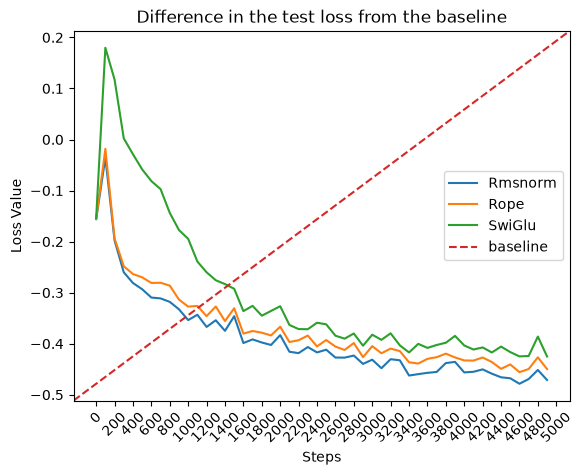

In [41]:
### Plotting the difference from the baseline
sns.lineplot(x = 'steps', y = 'test_rmsnorm_baseline', data = model_difference, label = 'Rmsnorm')
sns.lineplot(x = 'steps', y = 'test_rope_baseline', data = model_difference, label = 'Rope')
sns.lineplot(x = 'steps', y = 'test_glu_baseline', data = model_difference, label = 'SwiGlu')
plt.plot([0,1],[0,1], transform = plt.gca().transAxes, linestyle = '--', label = 'baseline')
plt.xticks(np.arange(0,5001, 200), rotation = 45)
plt.ylabel('Loss Value')
plt.xlabel('Steps')
plt.title('Difference in the test loss from the baseline')
plt.legend()
plt.show()

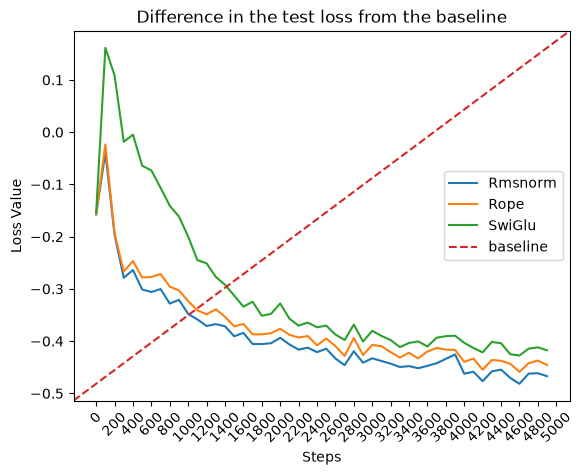

In [42]:
sns.lineplot(x = 'steps', y = 'train_rmsnorm_baseline', data = model_difference, label = 'Rmsnorm')
sns.lineplot(x = 'steps', y = 'train_rope_baseline', data = model_difference, label = 'Rope')
sns.lineplot(x = 'steps', y = 'train_glu_baseline', data = model_difference, label = 'SwiGlu')
plt.plot([0,1],[0,1], transform = plt.gca().transAxes, linestyle = '--', label = 'baseline')
plt.xticks(np.arange(0,5001, 200), rotation = 45)
plt.ylabel('Loss Value')
plt.xlabel('Steps')
plt.title('Difference in the test loss from the baseline')
plt.legend()
plt.show()